<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

## Torção de barras elásticas. Parte III
## Problema 5 <a name="PV135"></a>

A figura representa um veio de aço maciço $ABCD$ composto pelo troço $AB$ com 80 mm de diâmetro e 500 mm de comprimento e $CD$ com 85 mm de diâmetro e 600 mm de comprimento. Despreze qualquer efeito de concentração de tensões e considere que o aço tem comportamento elastoplástico com $G =$ 77 GPa e $\tau_C$ = 145 MPa.

[a)](#A) Calcule o valor do momento de torção aplicado sobre o veio $M_T$ que provoca o aparecimento da tensão de cedência na periferia do troço $CD$.

[b)](#B) Para o momento calculado na alínea a), determine o ângulo de torção $\phi$ que ocorrerá entre as extremidades $A$ e $D$ e represente a distribuição de tensões tangenciais correspondente para os dois troços $AB$ e $CD$.

[c)](#C) Considere agora que $M_T$ era retirado e determine a distribuição das tensões residuais e a rotação residual $\phi_R$ entre $A$ e $D$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au13/Au13_P005_i1.jpg"
width="400" height="280">

In [1]:
import numpy as np
import math
from matplotlib import pyplot as plt
from matplotlib.patches import Arc

plt.rcParams['axes.facecolor'] = (.15, .15, .15)
plt.rcParams['figure.facecolor'] = (.15, .15, .15)
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 14
# plt.rcParams['text.usetex'] = True
params = {"ytick.color" : (.8, .8, .8),
          "xtick.color" : (.8, .8, .8),
          "grid.color" : (.2, .2, .2),
          "text.color" : (.7, .7, .7),
          "axes.labelcolor" : (.8, .8, .8),
          "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# Dados
# unidades: m, Pa, N

dAB = 80.*1e-3 # unidade: m
rAB = dAB/2
LAB = 500.*1e-3  # unidade: m

dCD = 85.*1e-3
rCD = dCD/2
LCD = 600.*1e-3  # unidade: m

G = 77.e9 # unidade: Pa
TauC = 145.e6 # unidade: Pa

#### a) Calcule o valor do momento de torção aplicado sobre o veio $M_T$ que provoca o aparecimento da tensão de cedência na periferia do troço $CD$.<a name="A"></a> ([_enunciatum_](#PV135))

O cenário descrito no enunciado para o veio de maior secção $CD$ corresponde à ocorrência de cedência na periferia do veio maciço de um material com comportamento elasto-plástico perfeito (Fig (b)).

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au13/Au13_P005_i2.jpg"
width="700">

De acordo com a fórmula de torção a tensão máxima instalada nesse ponto periférico ($\rho = c = r_e$):

\begin{equation*}
\left( \tau_\mathrm{max} \equiv \tau_{C} = \frac{Tc}{J} \right)_{CD}
\quad\therefore\quad
\left(T_{C} = \frac{\tau_{C} J}{c} \right)_{CD}
\end{equation*}

In [2]:
JCD = np.pi/2*rCD**4
print(f'JCD = {JCD:.5e} m^4')
TCCD = TauC*JCD/rCD
print(f'TC (veio CD) (tau cedência) = {TCCD:.2f} N.m (sinal positivo : sentido anti-horário)')

JCD = 5.12478e-06 m^4
TC (veio CD) (tau cedência) = 17484.56 N.m (sinal positivo : sentido anti-horário)


#### b) Para o momento calculado na alínea a), determine o ângulo de torção $\phi$ que ocorrerá entre as extremidades $A$ e $D$ e represente a  distribuição de tensões tangenciais correspondente para os dois troços $AB$ e $CD$.<a name="B"></a> ([_enunciatum_](#PV135))

- Troço $CD$:

O troço $CD$ do veio permanece no limite elástico, pelo que o ângulo de torção será dado por:

\begin{equation*}
\phi_{C/D} = \phi_{C} - \phi_{D}
\quad\wedge\quad
\phi_{C/D} = \frac{T_CL}{JG}
\end{equation*}

In [3]:
phiCD = TCCD*LCD/JCD/G
print(f'phiC (veio CD) = {phiCD:.4f} rad | {np.rad2deg(phiCD):.2f} º')

phiC (veio CD) = 0.0266 rad | 1.52 º


A distribuição das tensões de corte no veio de maior secção $CD$ variam linearmente ao longo do raio (medido em relação ao centro do veio) de acordo com a gráfico:

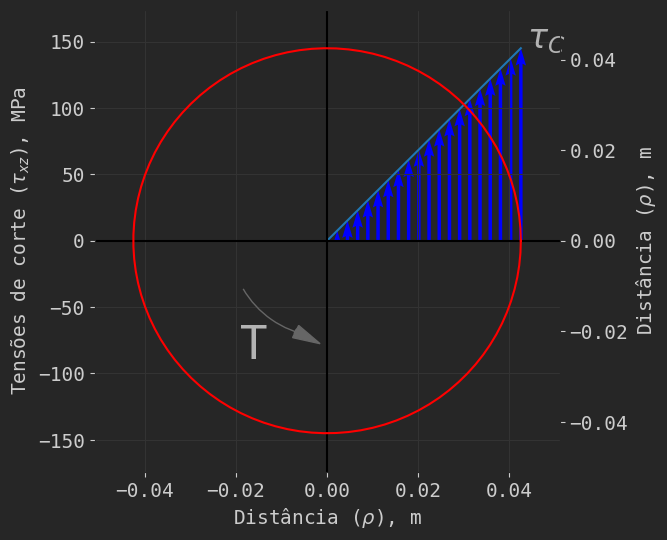

In [4]:
def torcao(rho,T,J): return T*rho/J

tauxzCD = TauC*1e-6

limits = np.array([[-rCD*1.2,rCD*1.2],[-tauxzCD*1.2,tauxzCD*1.2]])
xp1 = np.linspace(0,rCD,20)
yp1 = torcao(xp1,TCCD,JCD)*1e-6
fig, ax = plt.subplots(figsize=(6,6))
ax2 = ax.twinx()
ax.plot(xp1,yp1)
ax.quiver(xp1, np.zeros(xp1.shape), np.zeros(xp1.shape), yp1,color='blue', scale=350)
ax.set(xlabel=r'Distância ($\rho$), m', ylabel=r'Tensões de corte ($\tau_{xz}$), MPa')
ax.text(rCD*1.03,tauxzCD,r'$\tau_C$',size=24)
theta = np.linspace(0, 2*np.pi, 100)
x1 = rCD*np.cos(theta)
x2 = rCD*np.sin(theta)
ax2.plot(x1, x2,color='red')
ax2.set(ylabel=r'Distância ($\rho$), m')
x0, y0 = 0, 0
angle = 260
angle_rad = angle * math.pi / 180
arc_radius = rCD
arc = Arc((x0, y0),arc_radius, arc_radius,theta1=210, theta2=260,
          linestyle='solid',color=(0.4,0.4,0.4))
ax2.add_patch(arc)
ax2.arrow(-0.007,-0.02,0.01* 0.01,-.005* 0.01,head_width=0.003,head_length=0.006,color=(0.4,0.4,0.4))
ax2.text(-.019,-.026,'T',fontsize=33)
ax.set_xlim(limits[0,0],limits[0,1])
ax.set_ylim(limits[1,0],limits[1,1])
ax2.set_ylim(limits[0,0],limits[0,1])
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.grid()
plt.show()

- Troço $AB$:

O troço do veio $AB$ é de menor secção pelo que a hipótese de partida é que o veio irá provavelmente  entrar em plasticidade. Para verificar esta hipótese, comece-se por determinar a tensão limite de elástica máxima, $(T_C)_{AB}$, que o veio pode suportar:

\begin{equation*}
\left(\tau_C = \frac{T_Cc}{J}\right)_{AB}
\quad\wedge\quad J_{AB} = \frac{\pi}{2}c^4
\qquad\therefore\qquad
\left(T_C = \frac{\tau_C J}{c}\right)_{AB}
\end{equation*}

In [5]:
JAB = np.pi/2*rAB**4
print(f'JAB = {JAB:.5e} m^4')
TCAB = TauC*JAB/rAB
print(f'TC (veio AB) = {TCAB:.2f} N.m (sinal positivo : sentido anti-horário)')

JAB = 4.02124e-06 m^4
TC (veio AB) = 14576.99 N.m (sinal positivo : sentido anti-horário)


Conclui-se portanto que o valor do momento torsor aplicado, $T_{CD} = 17484.56$ N.m, é superior ao valor crítico, $(T_C)_{AB} = 14576.99$ N.m, pelo que o veio $AB$ consegue suportar pelo que ocorrerá plasticidade.

Ocorrendo plasticidade do veio, é contudo necessário verificar agora se o veio está partialmente plastificado (na sua periferia, havendo um núcleo elástico) ou completamente em regime plástico.

A expressão matemática do modelo para o domínio plástico do veio maciço $AB$ estabelece uma relação cúbica entre o momento de torção e o raio crítico (de separação da coroa central elástica da zona plástica periférica) dada por:

\begin{equation*}
\left[T = \frac{4}{3}T_C\left(1-\frac{1}{4}\frac{\rho_C^3}{c^3}\right)\right]
_{AB}
\end{equation*}

Consierando $T = T_{CD}= 17484.56$ N.m, esta expressão pode ser convenientemente resolvida para o valor do raio crítico $\rho_C$, entre o núcleo elástico e a coroa plástica:

\begin{equation*}
\rho_C = \left[4c^3\left(1-\frac{3}{4}\frac{T}{T_C}\right)\right]^{1/3}
\end{equation*}

rho C (veio AB) = 0.0295 m
percentagem elástico do veio 73.8 %


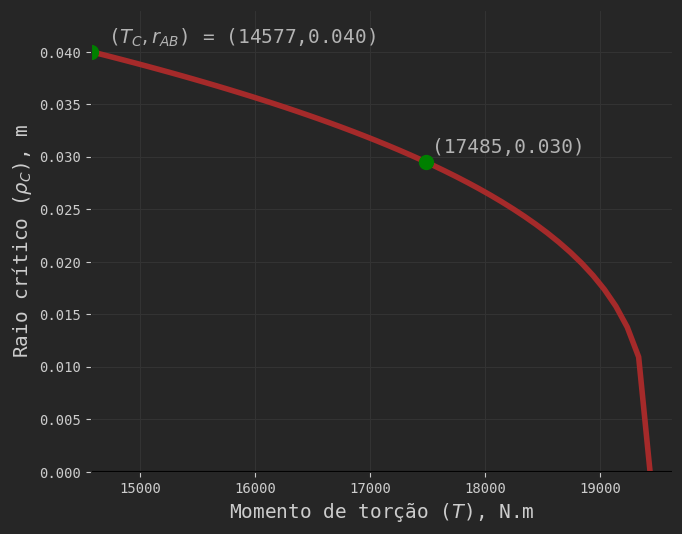

In [6]:
Tplim  = 4/3*TCAB
rhoCAB = (4*rAB**3*(1-3/4*TCCD/TCAB))**(1/3)
print(f'rho C (veio AB) = {rhoCAB:.4f} m')

percepAB = rhoCAB/rAB*100
print(f'percentagem elástico do veio {percepAB:.1f} %')

varT = np.linspace(TCAB,Tplim)
varrho = (4*rAB**3*(1-3/4*varT/TCAB))**(1/3)

rho1, Tor1 = rhoCAB, TCCD

fig, ax = plt.subplots(figsize=(7.5,6))
ax.plot(varT, varrho, '-', linewidth=4, color='brown')
ax.plot(Tor1, rho1, 'go', markersize=10)
plt.text(Tor1*1.003,rho1*1.03,f'({Tor1:.0f},{rho1:.3f})',fontsize=14)
ax.plot(TCAB, rAB, 'go', markersize=10)
plt.text(TCAB*1.01,rAB*1.02,rf'($T_C, r_{{AB}}$) = ({TCAB:.0f},{rAB:.3f})',
         fontsize=14)
plt.xlabel(r'Momento de torção ($T$), N.m',fontsize=14)
plt.ylabel(r'Raio crítico ($\rho_C$), m',fontsize=14)
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(TCAB*1.,Tplim*1.01)
plt.ylim(0,rAB*1.1)
# plt.ylim(0,200)
ax.grid()
plt.show()

De onde se conclui que o veio $AB$ está parcialmente elástico em 73.8%: $\rho_c =  0.0295$ m; $c=(r_e)_{AB} = 42.5$ m.

**Distribuição das tensões**

A distribuição das tensões de corte na secção do veio $AB$ vem:

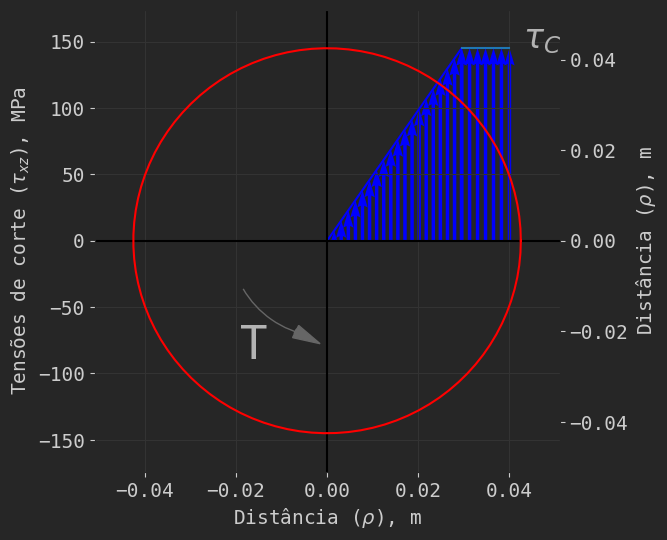

In [7]:
def distensveioab():
    limits = np.array([[-rCD*1.2,rCD*1.2],[-tauxzCD*1.2,tauxzCD*1.2]])
    xp1e = np.linspace(0,rhoCAB,20)
    yp1e = torcao(xp1,TCCD,JCD)*1e-6
    xp1p = np.linspace(rhoCAB,rAB,7)
    yp1p = np.ones(xp1p.shape)*tauxzCD
    fig, ax = plt.subplots(figsize=(6,6))
    ax2 = ax.twinx()
    ax.plot(xp1e,yp1e,'-b')
    ax.quiver(xp1e, np.zeros(xp1e.shape), np.zeros(xp1e.shape), yp1e,color='blue', scale=350)
    ax.plot(xp1p,yp1p)
    ax.quiver(xp1p, np.zeros(xp1p.shape), np.zeros(xp1p.shape), yp1p,color='blue', scale=350)
    ax.set(xlabel=r'Distância ($\rho$), m', ylabel=r'Tensões de corte ($\tau_{xz}$), MPa')
    ax.text(rCD*1.01,tauxzCD,r'$\tau_C$',size=24)
    theta = np.linspace(0, 2*np.pi, 100)
    x1 = rCD*np.cos(theta)
    x2 = rCD*np.sin(theta)
    ax2.plot(x1, x2,color='red')
    ax2.set(ylabel=r'Distância ($\rho$), m')
    x0, y0 = 0, 0
    angle = 260
    angle_rad = angle * math.pi / 180
    arc_radius = rCD
    arc = Arc((x0, y0),arc_radius, arc_radius,theta1=210, theta2=260, linestyle='solid',color=(0.4,0.4,0.4))
    ax2.add_patch(arc)
    ax2.arrow(-0.007,-0.02,0.01* 0.01,-.005* 0.01,head_width=0.003,head_length=0.006,color=(0.4,0.4,0.4))
    ax2.text(-.019,-.026,'T',fontsize=33)
    ax.set_xlim(limits[0,0],limits[0,1])
    ax.set_ylim(limits[1,0],limits[1,1])
    ax2.set_ylim(limits[0,0],limits[0,1])
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    ax.grid()
    plt.show()

distensveioab()


Didátivo:

#### c) Considere agora que $M_T$ era retirado e determine a distribuição das tensões residuais e a rotação residual $\phi_R$ entre $A$ e $D$.<a  name="C"></a> ([_enunciatum_](#PV135))

**Ângulo de torção residual**

Para analisar as tensões e rotação residuais é útil construir o gráfico ou diagrama do momento de torção em função do ângulo de torção. Para esse efeito calcule-se para o troço $AB$ do veio o limite do momento plástico dado, para veios maciços, pela expressão:

\begin{equation*}
\left(T_P = \frac{4}{3}T_C\right)_{AB}
\end{equation*}

In [8]:
TpAB = 4/3*TCAB
print(f'Tp (veio AB) = {TpAB:.2f} N.m (sinal positivo : sentido anti-horário)')

Tp (veio AB) = 19435.99 N.m (sinal positivo : sentido anti-horário)


**Veio $AB$**

Para analisar o ângulo de torção comece-se por calcular o ângulo de torção que o veio $AB$ (parcialmente plástico) sobre pela aplicação do momento torsor $M_T = 17484.56$ N.m. Como o regime é plástico, o cálculo do ângulo de torção pode ser determinado atendendo às seguintes relações.

No regime plástico permanece válida a relação:

\begin{equation*}
\gamma_{x\theta} \equiv \gamma = r \frac{\phi}{L}
\end{equation*}

A uma certa distância radial ($r$), o valor da distorção angular ($\gamma$) será o valor crítico (limite de elasticidade), $\gamma_C$, pelo que se pode resolver a equação anterior para o raio crítico ($r= \rho_C$):

\begin{equation*}
\rho_C = L \frac{\gamma_C}{\phi}
\end{equation*}

Atendendo à relação: $\tau_C = G\gamma_C ~\wedge~\phi_C = \tau_C L/G\rho_C$, a última expresão resulta:

\begin{equation*}
\rho_C = \frac{L\gamma_C}{\phi} = c \frac{\phi_C}{\phi} =
\quad\Leftrightarrow\quad
\left(\phi = \left(\frac{c}{\rho_C} \right) \phi_C\right)_{AB}
\end{equation*}

O valor de $(\phi)_{AB}$ corresponde ao ângulo de torção do veio $AB$ face ao momento torsor aplicado. O valor crítico $\phi_C$ pode ser calculado pela relação (domínio elástico),

\begin{equation*}
\left(\phi_C = \frac{T_C L}{JG}\right)_{AB}
\end{equation*}

In [9]:
phiCAB = TCAB*LAB/JAB/G
print(f'phiC (veio AB) = {phiCAB:.4f} rad | {np.rad2deg(phiCAB):.2f} º')

phiC (veio AB) = 0.0235 rad | 1.35 º


Pelo que,

\begin{equation*}
\phi_{A/B} = \left(\frac{c}{\rho_C} \right) \frac{T_C L}{JG}
\end{equation*}

In [23]:
phiAB = phiCAB*(rAB/rhoCAB)
print(f'phi (veio AB) = {phiAB:.4f} rad | {np.rad2deg(phiAB):.2f} º')

phi (veio AB) = 0.0319 rad | 1.83 º


**Veio $AD$**

O ângulo de torção total do veio $AD$ é dado pela combinação linear dos ângulos de torção dos troços que constituem o veio:

\begin{equation*}
\phi_{A/D} \equiv \phi_A = \phi_{A/B} + \phi_{C/D}
\quad\wedge\quad
\phi_{A/B} = \left(\frac{c}{\rho_C} \right) \frac{T_C L}{JG}
\quad\wedge\quad
\phi_{C/D} = \frac{T_CL}{JG}
\end{equation*}

In [24]:
phiAD = phiAB + phiCD
print(f'phiAD = {phiAD:.4f} rad | {np.rad2deg(phiAD):.2f} º')

phiAD = 0.0585 rad | 3.35 º


O troço do veio $CD$ deforma-se no regime elástico, pelo que recupera completamente a rotação causada pelo momento torsor, logo que este é removido. Contudo o troço $AB$ do veio deforma-se plasticamente e sofre deformação permanente ou residual quando o momento torsor é retirado. Desta forma, a análise das tensões residuais e do ângulo de torção residual incide sobre a análise do comportamento plástico do veio $AB$.

O ângulo de torção residual é determinado pelo princípio da sobreposição (carga + descarga elástica). Este é dado por:

\begin{equation*}
\left(\phi_{R} = \phi_{A/D} - \phi\,{'}\right)_{AD}
\end{equation*}

com,

\begin{equation*}
\begin{cases}
\phi_{A/D} \equiv \phi_{A} =  \phi_{A/B} + \phi_{C/D} \\
\phi\,{'} = \phi_{A/B}^{\,{'}} + \phi_{C/D}^{\,{'}} =
\left(\displaystyle\frac{TL}{JG}\right)_{AB} +
\left(\displaystyle\frac{TL}{JG}\right)_{AB}
\end{cases}
\end{equation*}

In [30]:
phidescargaAB = TCCD*LAB/JAB/G
print(f'phi descarga linear (AB) = {phidescargaAB:.4f} rad | {np.rad2deg(phidescargaAB):.2f} º')

phidescargaCD = TCCD*LCD/JCD/G
print(f'phi descarga linear (CD) = {phidescargaCD:.4f} rad | {np.rad2deg(phidescargaCD):.2f} º')

phidescarga = phidescargaAB + phidescargaCD
print(f'phi descarga linear (total) = {phidescarga:.4f} rad | {np.rad2deg(phidescarga):.2f} º')

phiResidual = phiAD -phidescarga
print(f'phi residual = {phiResidual:.4f} rad | {np.rad2deg(phiResidual):.2f} º')

phi descarga linear (AB) = 0.0282 rad | 1.62 º
phi descarga linear (CD) = 0.0266 rad | 1.52 º
phi descarga linear (total) = 0.0548 rad | 3.14 º
phi residual = 0.0037 rad | 0.21 º


Uma vez que o comportamento da barra $CD$ permanece elástico, $\phi_{C/D} = \phi_{C/D}^{\,{'}}$, é possível fazer a seguinte simplificação :

\begin{equation*}
\left(\phi_{R} = \phi_{A/D} - \phi\,{'}\right)_{AD}
\quad\Leftrightarrow\quad
\phi_{R} = \phi_{A/B} + \phi_{C/D} - \phi_{A/B}^{\,{'}} + \phi_{C/D}^{\,{'}}
= \phi_{A/B} - \phi_{A/B}^{\,{'}}
\end{equation*}

Ou seja a análise das rotações residuais para o veio $AD$ pode ser veito considerando apenas o comportamento de recuperação elástica do veio parcialmente plástico $AB$.

In [33]:
phiResidual2 = phiAB - phidescargaAB
print(f'phi residual (cálculo 2) = {phiResidual2:.5f} rad | {np.rad2deg(phiResidual2):.2f} º')

phi residual (cálculo 2) = 0.00367 rad | 0.21 º


**Resumo: ângulo de torção redisual**

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au13/Au13_P005_i3.jpg"
width="800">

**Tensões residuais - Troço AB**

As tensões residuais no material elastoplástico são obtidas por aplicando o princípio de superposição.

Por um lado, consideram-se as tensões devidas à aplicação do momento torsor, $T$. Por outro lado, são consideradas as tensões devido ao momento de torção, igual e oposto, que é aplicado
na fase de descarga.

O primeiro grupo de tensões reflete o comportamento elasto-plástico do material durante a fase de carregamento. O segundo grupo tem o comportamento linear do mesmo material durante o estágio de descarga. A adição dos dois grupos de tensões fornece a distribuição das tensões residuais no eixo.

Na descarga, a tensão de corte varia linearmente e a tensão máxima ($\tau_\mathrm{max}$) ocorre na periferia do veio ($r_e$):

\begin{equation*}
\left(\tau_\mathrm{max} = \displaystyle\frac{(-T) c}{J}\right)_{AB}
\end{equation*}

In [34]:
taurhoCABDescarga =  -TCCD*rhoCAB/JAB
print(f'tau (rhoC)  -veio AB- (Descarga) = {taurhoCABDescarga*1e-6:.2f} MPa')

tau (rhoC)  -veio AB- (Descarga) = -128.32 MPa


Além deste valor é necessário ainda calcular o valor da descarga associado à aplicação do momento torsor $T$ no sentido contrário, para a coordenada radial do limite elástico $\rho_C$:

\begin{equation*}
\left(\tau(\rho = \rho_C) = \displaystyle\frac{(-T) \rho_C}{J}\right)_{AB}
\end{equation*}

In [35]:
taumaxABDescarga =  -TCCD*rAB/JAB
print(f'tau max -veio AB- (Descarga) = {taumaxABDescarga*1e-6:.2f} MPa')

tau max -veio AB- (Descarga) = -173.92 MPa


Assim sendo as tensões residuais têm uma distribuição linear cujos valores no ponto interior e exterior ao veio oco são determinados por:

\begin{equation*}
\begin{cases}
\tau_1^R = \tau_C + \tau(\rho_C) \\
\tau_2^R = \tau_C + \tau_\mathrm{max}
\end{cases}
\end{equation*}

In [36]:
TauR1 = TauC + taurhoCABDescarga
print(f'tau Residual (rhoC) = {TauR1*1e-6:.2f} MPa')

TauR2 = TauC + taumaxABDescarga
print(f'tau Residual (re) = {TauR2*1e-6:.2f} MPa')


tau Residual (rhoC) = 16.68 MPa
tau Residual (re) = -28.92 MPa


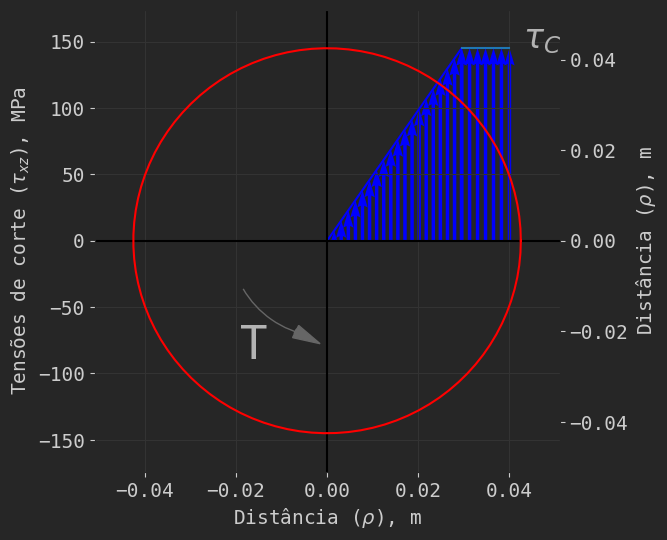

In [17]:
distensveioab()

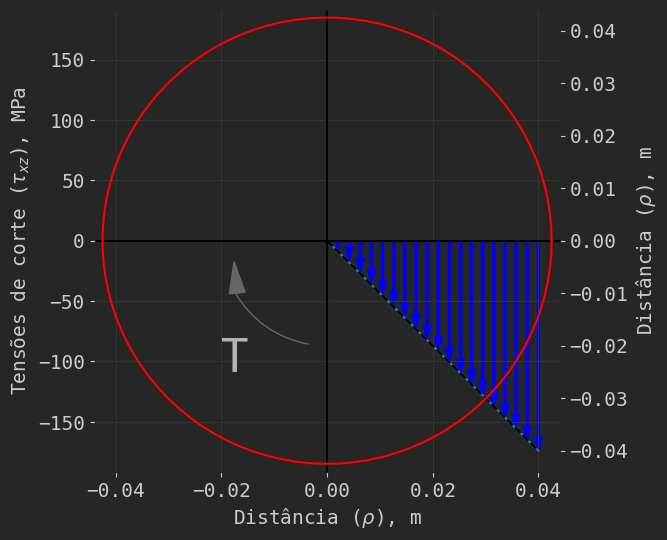

In [18]:
Tplt1 = taurhoCABDescarga*1e-6 # unidade: MPa
Tplt2 = taumaxABDescarga*1e-6

limits = np.array([[-rAB*1.1,rAB*1.1],[Tplt2*1.1,-Tplt2*1.1]])
xp1 = np.linspace(0,rAB,20)
yp1 = -TCCD*xp1/JAB*1e-6
fig, ax = plt.subplots(figsize=(6,6))
ax2 = ax.twinx()
ax.plot(xp1,yp1)
ax.plot([0,xp1[-1]],[0,yp1[-1]],'k--')
ax.quiver(xp1, np.zeros(xp1.shape), np.zeros(xp1.shape), yp1,color='blue',
          scale=380)
ax.set(xlabel=r'Distância ($\rho$), m', ylabel=r'Tensões de corte ($\tau_{xz}$), MPa')
theta = np.linspace(0, 2*np.pi, 100)
x1i = rAB*np.cos(theta)
x2i = rAB*np.sin(theta)
ax2.plot(x1, x2,color='red')
ax2.set(ylabel=r'Distância ($\rho$), m')
x0, y0, angle, arc_radius = 0, 0, 260, rAB
angle_rad = angle * math.pi / 180
arc = Arc((x0, y0),arc_radius, arc_radius,theta1=210, theta2=260,
          linestyle='solid',color=(0.4,0.4,0.4))
ax2.add_patch(arc)
arc_arrow_length = rAB/2
arc_arrow_dx = arc_arrow_length * math.cos(angle_rad + math.pi / 2)
arc_arrow_dy = arc_arrow_length * math.sin(angle_rad + math.pi / 2)
ax2.arrow(-0.017,-0.01,-.0005* 0.01,0.005* 0.01,head_width=0.003,head_length=0.006,color=(0.4,0.4,0.4))
ax2.text(-.020,-.025,'T',fontsize=33)
ax.set_xlim(limits[0,0],limits[0,1])
ax.set_ylim(limits[1,0],limits[1,1])
ax2.set_ylim(limits[0,0],limits[0,1])
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.grid()
plt.show()

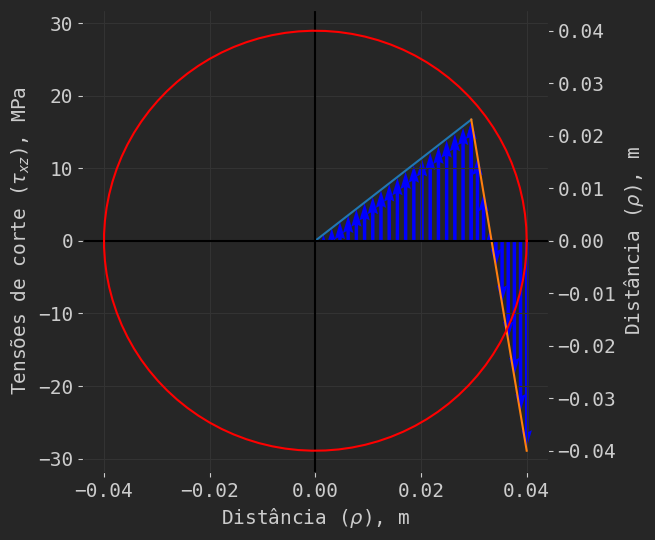

In [19]:
TauR1plt = TauR1*1e-6 # unidades: MPa
TauR2plt = TauR2*1e-6

limits = np.array([[-rAB*1.1,rAB*1.1],[TauR2plt*1.1,-TauR2plt*1.1]])
xp1 = np.linspace(0,rhoCAB,20)
yp1 = np.linspace(0,TauR1plt,20)
xp2 = np.linspace(rhoCAB,rAB,10)
yp2 = np.linspace(TauR1plt,TauR2plt,10)
fig, ax = plt.subplots(figsize=(6,6))
ax2 = ax.twinx()
ax.plot(xp1,yp1)
ax.quiver(xp1, np.zeros(xp1.shape), np.zeros(xp1.shape), yp1,color='blue', scale=65)
ax.plot(xp2,yp2)
ax.quiver(xp2, np.zeros(xp2.shape), np.zeros(xp2.shape), yp2,color='blue', scale=65)
ax.set(xlabel=r'Distância ($\rho$), m', ylabel=r'Tensões de corte ($\tau_{xz}$), MPa')
theta = np.linspace(0, 2*np.pi, 100)
x1i = rAB*np.cos(theta)
x2i = rAB*np.sin(theta)
ax2.plot(x1i, x2i,color='red')
ax2.set(ylabel=r'Distância ($\rho$), m')
ax.set_xlim(limits[0,0],limits[0,1])
ax.set_ylim(limits[1,0],limits[1,1])
ax2.set_ylim(limits[0,0],limits[0,1])
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.grid()
plt.show()

##### Bibliografia

[1]  Ferdinand P. Beer, E. Russell Johnston Jr., John T. DeWolf, David F. Mazurek. Mechanics of Materials. McGraw-Hill Education, 2014.

[2] Russell C. Hibbeler. Mechanics of Materials. Pearson, 2016.

[3] Timothy A. Philpot. Mechanics of materials: an integrated learning system. John Wiley & Sons, 2017.

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
